In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score,f1_score,r2_score, classification_report,confusion_matrix

from google.colab import files
import io
uploaded = files.upload()

df = pd.read_csv(io.BytesIO(uploaded['survey.csv']))

df.head(5)

Saving survey.csv to survey.csv


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [2]:
print("Shape(rows,cols):",df.shape)

Shape(rows,cols): (1259, 27)


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [4]:
print("\nMissing values:\n",df.isnull().sum())


Missing values:
 Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64


In [5]:
df = df.drop(['state','comments','Timestamps'],axis=1, errors='ignore')

In [6]:
df["self_employed"] = df["self_employed"].fillna(df["self_employed"].mode()[0])

In [7]:
df["work_interfere"] = df["work_interfere"].fillna(df["work_interfere"].mode()[0])

In [8]:
print("\nMissinf values After cleaning")
print(df.isnull().sum())
print("\nAfter cleaning:", df.shape)


Missinf values After cleaning
Timestamp                    0
Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64

After cleaning: (1259, 25)


In [9]:
df.head()

,Timestamp,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,2014-08-27 11:29:31,37,Female,United States,No,No,Yes,Often,6-25,No,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,2014-08-27 11:29:37,44,M,United States,No,No,No,Rarely,More than 1000,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,2014-08-27 11:29:44,32,Male,Canada,No,No,No,Rarely,6-25,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,2014-08-27 11:29:46,31,Male,United Kingdom,No,Yes,Yes,Often,26-100,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,2014-08-27 11:30:22,31,Male,United States,No,No,No,Never,100-500,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No


In [10]:
df = df.drop(['Timestamp'],axis=1)

In [11]:
print(df.head(5))

   Age  Gender         Country self_employed family_history treatment  \
0   37  Female   United States            No             No       Yes   
1   44       M   United States            No             No        No   
2   32    Male          Canada            No             No        No   
3   31    Male  United Kingdom            No            Yes       Yes   
4   31    Male   United States            No             No        No   

  work_interfere    no_employees remote_work tech_company  ...   anonymity  \
0          Often            6-25          No          Yes  ...         Yes   
1         Rarely  More than 1000          No           No  ...  Don't know   
2         Rarely            6-25          No          Yes  ...  Don't know   
3          Often          26-100          No          Yes  ...          No   
4          Never         100-500         Yes          Yes  ...  Don't know   

                leave mental_health_consequence phys_health_consequence  \
0       Somewhat 

In [12]:
df = df[(df["Age"]>= 15) & (df["Age"]<= 75)]

In [13]:
df["Gender"] = df["Gender"].str.lower().str.strip()
df["Gender"] = df["Gender"].replace({
    "male":       "Male", "m":    "Male",
    "man":        "Male", "maile":"Male",
    "cis male":   "Male", "male ":"Male",
    "female":     "Female", "f":  "Female",
    "woman":      "Female", "cis female": "Female",
    "female ":    "Female"
})
df["Gender"] = df["Gender"].apply(
    lambda x: x if x in ["Male","Female"] else "Other"
)

In [14]:
print("After cleaning:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nGender counts:")
print(df["Gender"].value_counts())
print("\nAge stats:")
print(df["Age"].describe().round(1))

After cleaning: (1251, 24)

Missing values:
Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64

Gender counts:
Gender
Male      975
Female    243
Other      33
Name: count, dtype: int64

Age stats:
count    1251.0
mean       32.1
std         7.3
min        18.0
25%        27.0
50%        31.0


In [15]:
print(df.columns.tolist())

['Age', 'Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence']


In [16]:
print(df["treatment"].value_counts())
print(df["treatment"].value_counts(normalize=True).round(2))

treatment
Yes    632
No     619
Name: count, dtype: int64
treatment
Yes    0.51
No     0.49
Name: proportion, dtype: float64


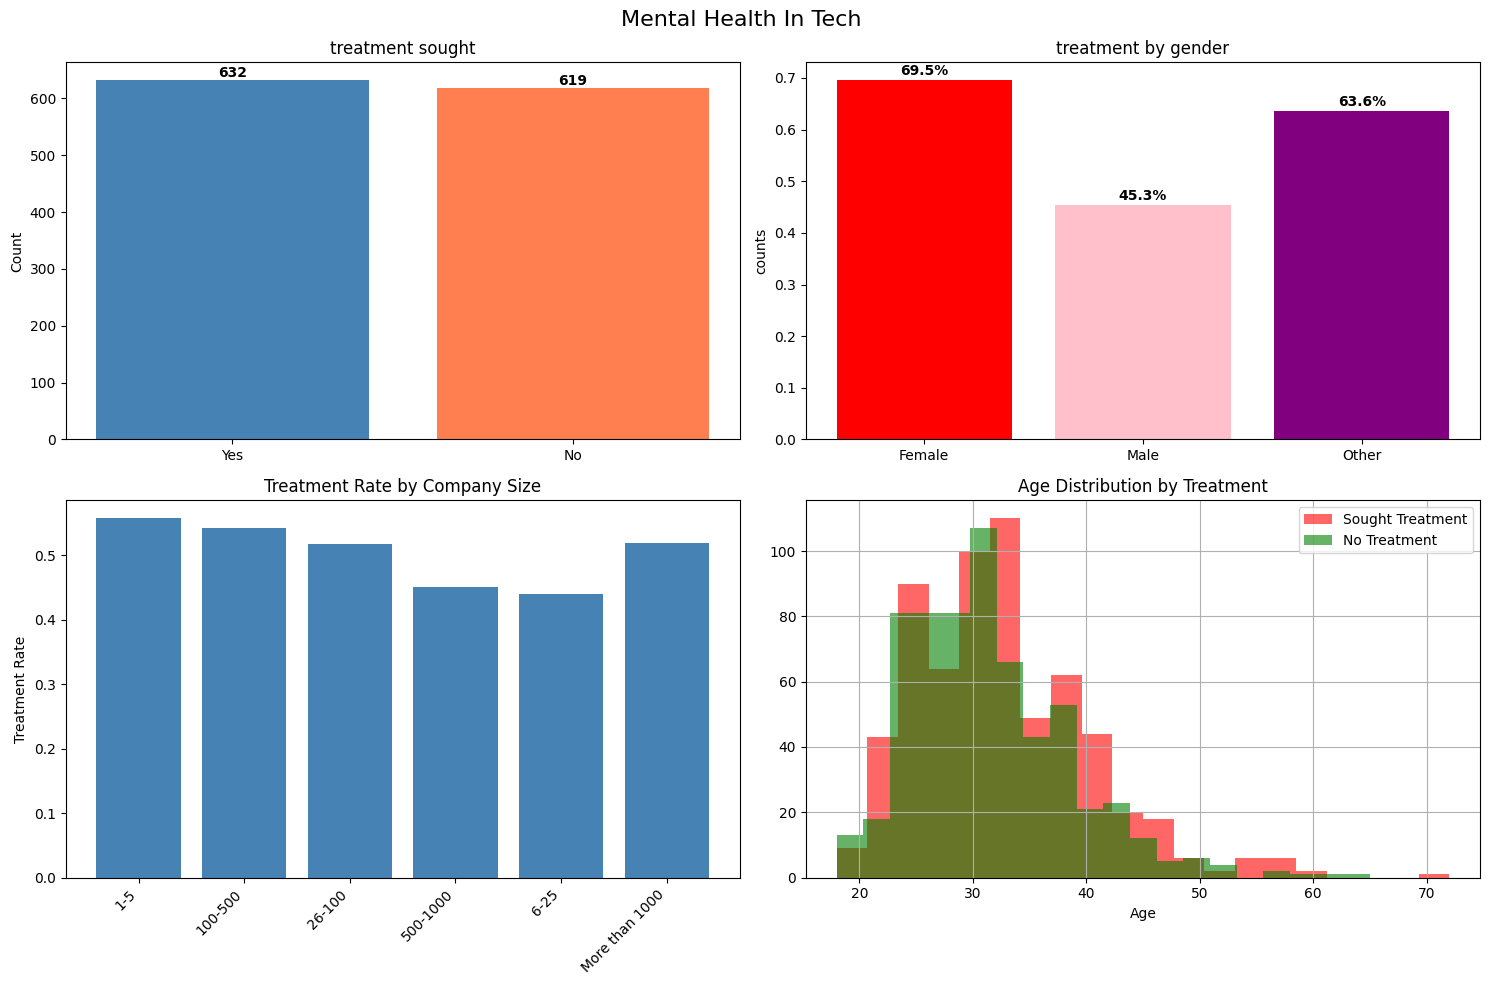

Overall treatment rate: 50.5%

Treatment rate by gender:
Gender
Female    69.5%
Male      45.3%
Other     63.6%
Name: treatment, dtype: object

Treatment rate by work interference:
work_interfere
Never        14.2%
Often        85.0%
Rarely       70.5%
Sometimes    49.7%
Name: treatment, dtype: object

Treatment rate by remote work:
remote_work
No     49.7%
Yes    52.6%
Name: treatment, dtype: object


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
fig.suptitle("Mental Health In Tech ", fontsize=16)


treatment_counts = df["treatment"].value_counts()
axes[0,0].bar(treatment_counts.index,treatment_counts.values,color=["steelblue","coral"])
axes[0,0].set_title("treatment sought")
axes[0,0].set_ylabel("Count")
for i, v in enumerate(treatment_counts.values):
  axes[0,0].text(i, v+5, str(v), ha="center", fontweight="bold")


gender_treatment = df.groupby("Gender")["treatment"].apply(lambda x : (x=="Yes").mean())
axes[0,1].bar(gender_treatment.index, gender_treatment.values, color=["red","pink","purple"])
axes[0,1].set_title("treatment by gender")
axes[0,1].set_ylabel("counts")
for i, v in enumerate(gender_treatment.values):
  axes[0,1].text(i,  v+0.01, f"{v*100:.1f}%",
                 ha="center",fontweight="bold")


company_treatment = df.groupby("no_employees")["treatment"].apply(
    lambda x: (x=="Yes").mean()
)
axes[1,0].bar(range(len(company_treatment)),
               company_treatment.values,
               color="steelblue")
axes[1,0].set_xticks(range(len(company_treatment)))
axes[1,0].set_xticklabels(company_treatment.index,
                            rotation=45, ha="right")
axes[1,0].set_title("Treatment Rate by Company Size")
axes[1,0].set_ylabel("Treatment Rate")


df[df["treatment"]=="Yes"]["Age"].hist(
    bins=20, ax=axes[1,1],
    alpha=0.6, color="red", label="Sought Treatment")
df[df["treatment"]=="No"]["Age"].hist(
    bins=20, ax=axes[1,1],
    alpha=0.6, color="green", label="No Treatment")
axes[1,1].set_title("Age Distribution by Treatment")
axes[1,1].set_xlabel("Age")
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f"Overall treatment rate: {(df['treatment']=='Yes').mean()*100:.1f}%")
print(f"\nTreatment rate by gender:")
print(df.groupby("Gender")["treatment"].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f}%"))
print(f"\nTreatment rate by work interference:")
print(df.groupby("work_interfere")["treatment"].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f}%"))
print(f"\nTreatment rate by remote work:")
print(df.groupby("remote_work")["treatment"].apply(
    lambda x: f"{(x=='Yes').mean()*100:.1f}%"))

In [18]:

def company_support(row):
  score=0
  if row["benefits"] == "Yes":score += 1
  if row["care_options"] == "Yes": score += 1
  if row["wellness_program"] == "Yes": score +=1
  if row["seek_help"] == "Yes": score +=1
  if row["anonymity"] == "Yes": score +=1
  return score

df["company_support_score"] = df.apply(company_support, axis=1)


def openness(row):
  score = 0
  if row["coworkers"]  in ["Yes", "Some of them"]: score += 1
  if row["supervisor"] in ["Yes", "Some of them"]: score += 1
  if row["mental_health_consequence"] == "No":     score += 1
  if row["obs_consequence"]           == "No":     score += 1
  if row["mental_health_interview"]   == "Yes":    score += 1
  return score

df["Openness_Score"] = df.apply(openness, axis=1)

def risk_level(row):
    score = 0
    if row["family_history"] == "Yes":         score += 2
    if row["work_interfere"] == "Often":        score += 2
    elif row["work_interfere"] == "Sometimes":  score += 1
    return score

df["Risk_Level"] = df.apply(risk_level, axis=1)


df["Is_Small_Company"] = df["no_employees"].apply(
    lambda x: 1 if x in ["1-5", "6-25"] else 0
)


df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 50, 75],
    labels=["Young","Adult","Senior","Elder"]
)


print(df[["Age_Group",
          "company_support_score",
          "Openness_Score",
          "Risk_Level",
          "Is_Small_Company"]].head(10))

print("\nCompany Support Score distribution:")
print(df["company_support_score"].value_counts().sort_index())

print("\nRisk Level distribution:")
print(df["Risk_Level"].value_counts().sort_index())

print(df["Country"].value_counts().head(10))

def get_region(country):
    us      = ["United States"]
    uk      = ["United Kingdom"]
    europe  = ["Germany","France","Netherlands",
               "Ireland","Sweden","Switzerland",
               "Belgium","Denmark","Finland",
               "Norway","Austria","Spain","Italy"]
    other   = ["Canada","Australia","India",
               "Brazil","New Zealand"]

    if country in us:     return "USA"
    elif country in uk:   return "UK"
    elif country in europe: return "Europe"
    else:                 return "Other"

df["Region"] = df["Country"].apply(get_region)
df = df.drop("Country", axis=1)

print("\nRegion distribution:")
print(df["Region"].value_counts())

  Age_Group  company_support_score  Openness_Score  Risk_Level  \
0    Senior                      3               4           2   
1    Senior                      0               1           0   
2     Adult                      0               5           0   
3     Adult                      1               1           4   
4     Adult                      1               5           0   
5     Adult                      1               4           3   
6     Adult                      0               2           3   
7    Senior                      2               2           0   
8    Senior                      2               3           3   
9     Young                      0               4           0   

   Is_Small_Company  
0                 1  
1                 0  
2                 1  
3                 0  
4                 0  
5                 1  
6                 1  
7                 1  
8                 0  
9                 0  

Company Support Score distribu

In [19]:
df["treatment"] = (df["treatment"] == "Yes").astype(int)

In [20]:
print(df["no_employees"].dtype)

object


In [21]:
numeric_features = [
    "Age",
    "company_support_score",
    "Openness_Score",
    "Risk_Level",
    "Is_Small_Company"
]

categorical_features = [
    "Gender",
    "Region",
    "self_employed",
    "family_history",
    "work_interfere",
    "no_employees",
    "remote_work",
    "tech_company",
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave",
    "coworkers",
    "supervisor",
    "mental_health_consequence",
    "phys_health_consequence",
    "mental_health_interview",
    "phys_health_interview",
    "mental_vs_physical",
    "obs_consequence",
    "Age_Group"
]
X = df[numeric_features + categorical_features]
y = df["treatment"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"\nTarget balance:")
print(f"Needs treatment:    {y.sum()} ({y.mean()*100:.1f}%)")
print(f"No treatment:       {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")

X shape: (1251, 28)
y shape: (1251,)

Target balance:
Needs treatment:    632 (50.5%)
No treatment:       619 (49.5%)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nTraining: {len(X_train)} rows")
print(f"Testing:  {len(X_test)} rows")


Training: 1000 rows
Testing:  251 rows


In [23]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline,     numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [24]:
from xgboost import XGBClassifier

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(
                               n_estimators=100,
                               learning_rate=0.1,
                               max_depth=3,
                               eval_metric="logloss",
                               random_state=42
                           )
}

results = {}
print(f"{'Model':25} {'Accuracy':>10} {'F1':>8} {'CV Mean':>10}")

for name,model in models.items():
  pipe = Pipeline(steps=[
      ("preprocessor", preprocessor),
      ("model", model)
  ])
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  cv = cross_val_score(pipe, X, y, cv=5).mean()

  results[name] = {
        "pipeline": pipe,
        "acc":      acc,
        "f1":       f1,
        "cv":       cv
    }

  print(f"{name:25} {acc*100:>9.1f}% {f1*100:>7.1f}% {cv*100:>9.1f}%")

best_name = max(results, key=lambda x: results[x]["cv"])
print(f"\nBest model: {best_name}")

Model                       Accuracy       F1    CV Mean
Logistic Regression            78.1%    78.1%      73.3%
Decision Tree                  72.9%    73.8%      71.9%
Random Forest                  78.5%    78.6%      74.7%
XGBoost                        81.3%    81.1%      74.5%

Best model: Random Forest


In [26]:
print("="*65)
print(f"{'Model':25} {'Train':>10} {'Test':>10} {'Gap':>8} {'Status'}")
print("="*65)

for name, result in results.items():
    pipe      = result["pipeline"]
    train_acc = accuracy_score(y_train, pipe.predict(X_train))
    test_acc  = result["acc"]
    gap       = train_acc - test_acc

    if gap > 0.1:
        status = "Overfitting!"
    elif test_acc < 0.70:
        status = "Underfitting!"
    else:
        status = "Good fit"

    print(f"{name:25} {train_acc*100:>9.1f}%"
          f" {test_acc*100:>9.1f}%"
          f" {gap*100:>7.1f}% {status}")

print("="*65)

Model                          Train       Test      Gap Status
Logistic Regression            76.8%      78.1%    -1.3% Good fit
Decision Tree                  78.0%      72.9%     5.1% Good fit
Random Forest                 100.0%      78.5%    21.5% Overfitting!
XGBoost                        82.3%      81.3%     1.0% Good fit


In [27]:
from sklearn.model_selection import GridSearchCV

In [28]:
param_grid = {
    "model__n_estimators":  [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth":     [3, 5],
    "model__subsample":     [0.8, 1.0]
}

tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters:")
for param, value in grid_search.best_params_.items():
    clean_param = param.replace("model__", "")
    print(f"  {clean_param:20} → {value}")

print(f"\nBefore tuning: {results['XGBoost']['cv']*100:.1f}%")
print(f"After tuning:  {grid_search.best_score_*100:.1f}%")

improvement = (grid_search.best_score_ -
               results["XGBoost"]["cv"]) * 100
print(f"Improvement:   +{improvement:.1f}%")

tuned_pipeline = grid_search.best_estimator_
print("\nTuned model ready")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters:
  learning_rate        → 0.05
  max_depth            → 3
  n_estimators         → 100
  subsample            → 0.8

Before tuning: 74.5%
After tuning:  74.8%
Improvement:   +0.3%

Tuned model ready


In [29]:
from sklearn.metrics import precision_score,recall_score

In [30]:
y_pred = tuned_pipeline.predict(X_test)
y_prob = tuned_pipeline.predict_proba(X_test)[:,1]

acc       = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print(f"Model:     Tuned XGBoost")
print(f"Accuracy:  {acc*100:.1f}%")
print(f"F1 Score:  {f1*100:.1f}%")
print(f"Precision: {precision*100:.1f}%")
print(f"Recall:    {recall*100:.1f}%")

Model:     Tuned XGBoost
Accuracy:  80.1%
F1 Score:  80.0%
Precision: 81.3%
Recall:    78.7%


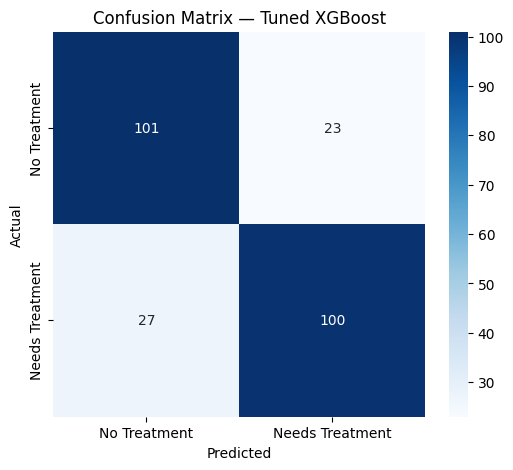

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Treatment","Needs Treatment"],
            yticklabels=["No Treatment","Needs Treatment"])
plt.title("Confusion Matrix — Tuned XGBoost")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [32]:
tn, fp, fn, tp = cm.ravel()
print(f"\n===== CONFUSION MATRIX EXPLAINED =====")
print(f"True Negative  (TN): {tn} → correctly predicted NO treatment")
print(f"False Positive (FP): {fp} → said needs treatment, actually didn't")
print(f"False Negative (FN): {fn} → missed someone who needed treatment!")
print(f"True Positive  (TP): {tp} → correctly predicted needs treatment")
print(f"\nFalse Negatives ({fn}) are most dangerous!")
print(f"These are people who NEED help but model missed them!")


===== CONFUSION MATRIX EXPLAINED =====
True Negative  (TN): 101 → correctly predicted NO treatment
False Positive (FP): 23 → said needs treatment, actually didn't
False Negative (FN): 27 → missed someone who needed treatment!
True Positive  (TP): 100 → correctly predicted needs treatment

False Negatives (27) are most dangerous!
These are people who NEED help but model missed them!


In [33]:
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred,
      target_names=["No Treatment","Needs Treatment"]))


===== CLASSIFICATION REPORT =====
                 precision    recall  f1-score   support

   No Treatment       0.79      0.81      0.80       124
Needs Treatment       0.81      0.79      0.80       127

       accuracy                           0.80       251
      macro avg       0.80      0.80      0.80       251
   weighted avg       0.80      0.80      0.80       251



In [34]:
cat_encoder  = (tuned_pipeline
                .named_steps["preprocessor"]
                .named_transformers_["cat"]
                .named_steps["encoder"])

cat_columns  = cat_encoder.get_feature_names_out(
               categorical_features)
all_features = numeric_features + list(cat_columns)
importances  = (tuned_pipeline
                .named_steps["model"]
                .feature_importances_)

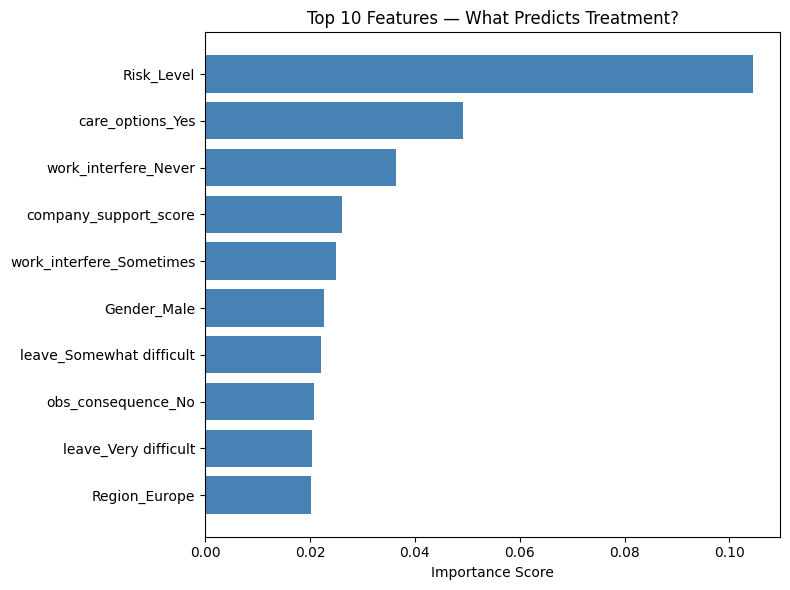


Top 5 features:
                     Feature  Importance
3                 Risk_Level    0.104436
35          care_options_Yes    0.049113
16      work_interfere_Never    0.036506
1      company_support_score    0.026089
19  work_interfere_Sometimes    0.025029


In [37]:
feat_df = pd.DataFrame({
    "Feature":    all_features,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(10)


plt.figure(figsize=(8, 6))
plt.barh(feat_df["Feature"],
         feat_df["Importance"],
         color="steelblue")
plt.title("Top 10 Features — What Predicts Treatment?")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(feat_df.head())

In [38]:
print("\n===== BEFORE vs AFTER TUNING =====")
print(f"{'Metric':15} {'Before':>10} {'After':>10} {'Change':>10}")
print("-"*50)
before_acc = results["XGBoost"]["acc"]
before_f1  = results["XGBoost"]["f1"]
print(f"{'Accuracy':15} {before_acc*100:>9.1f}% {acc*100:>9.1f}% "
      f"{(acc-before_acc)*100:>+9.1f}%")
print(f"{'F1 Score':15} {before_f1*100:>9.1f}% {f1*100:>9.1f}% "
      f"{(f1-before_f1)*100:>+9.1f}%")


===== BEFORE vs AFTER TUNING =====
Metric              Before      After     Change
--------------------------------------------------
Accuracy             81.3%      80.1%      -1.2%
F1 Score             81.1%      80.0%      -1.1%


In [39]:
print(f"XGBoost CV before tuning: {results['XGBoost']['cv']*100:.1f}%")
print(f"XGBoost CV after tuning:  {grid_search.best_score_*100:.1f}%")

XGBoost CV before tuning: 74.5%
XGBoost CV after tuning:  74.8%


In [40]:
cv_before = results["XGBoost"]["cv"]
cv_after  = grid_search.best_score_

print(f"CV before: {cv_before*100:.1f}%")
print(f"CV after:  {cv_after*100:.1f}%")

if cv_after >= cv_before:
    tuned_pipeline = grid_search.best_estimator_
    print("Keeping tuned model — CV improved!")
else:
    tuned_pipeline = results["XGBoost"]["pipeline"]
    print("Keeping original XGBoost — already optimal!")

CV before: 74.5%
CV after:  74.8%
Keeping tuned model — CV improved!


In [41]:
sample = X_test.iloc[[0, 5, 10]]

predictions  = tuned_pipeline.predict(sample)
probabilities = tuned_pipeline.predict_proba(sample)

print("="*55)
for i, (pred, prob) in enumerate(
        zip(predictions, probabilities)):
    label = "Needs Treatment" if pred==1 else "No Treatment"
    actual = "Needs Treatment" if y_test.iloc[i]==1 else "No Treatment"
    conf   = max(prob)*100
    print(f"Employee {i+1}:")
    print(f"  Predicted: {label} ({conf:.1f}%)")
    print(f"  Actual:    {actual}")
    print(f"  Correct:   {'1' if pred==y_test.iloc[i] else '0'}")
    print()

Employee 1:
  Predicted: Needs Treatment (59.7%)
  Actual:    Needs Treatment
  Correct:   1

Employee 2:
  Predicted: Needs Treatment (57.0%)
  Actual:    No Treatment
  Correct:   0

Employee 3:
  Predicted: No Treatment (86.8%)
  Actual:    Needs Treatment
  Correct:   0



In [42]:
new_employees = pd.DataFrame({
    "Age":                       [24,   45,   32  ],
    "Gender":                    ["Male","Female","Other"],
    "self_employed":             ["No","No","Yes"],
    "family_history":            ["No","Yes","Yes"],
    "work_interfere":            ["Never","Often","Sometimes"],
    "no_employees":              ["26-100","More than 1000","1-5"],
    "remote_work":               ["Yes","No","Yes"],
    "tech_company":              ["Yes","Yes","No"],
    "benefits":                  ["Yes","Yes","No"],
    "care_options":              ["Yes","No","No"],
    "wellness_program":          ["Yes","No","No"],
    "seek_help":                 ["Yes","No","No"],
    "anonymity":                 ["Yes","No","No"],
    "leave":                     ["Very easy","Very difficult","Somewhat difficult"],
    "coworkers":                 ["Yes","No","Some of them"],
    "supervisor":                ["Yes","No","No"],
    "mental_health_consequence": ["No","Yes","Yes"],
    "phys_health_consequence":   ["No","No","Yes"],
    "mental_health_interview":   ["Yes","No","No"],
    "phys_health_interview":     ["Yes","No","No"],
    "mental_vs_physical":        ["Yes","No","No"],
    "obs_consequence":           ["No","Yes","Yes"],

    "company_support_score":     [5,    1,    0  ],
    "Openness_Score":            [4,    0,    1  ],
    "Risk_Level":                [0,    4,    3  ],
    "Is_Small_Company":          [0,    0,    1  ],
    "Age_Group":                 ["Young","Adult","Adult"],
    "Region":                    ["USA","UK","Europe"]
})

predictions   = tuned_pipeline.predict(new_employees)
probabilities = tuned_pipeline.predict_proba(new_employees)

profiles = [
    "Junior Dev — supportive company",
    "Senior Dev — no support, family history",
    "Freelancer — isolated, high risk"
]

print("="*65)
print(f"{'Employee':<35} {'Result':<20} {'Confidence'}")
print("="*65)
for i, (pred, prob) in enumerate(
        zip(predictions, probabilities)):
    label = "Needs Treatment" if pred==1 else "No Treatment"
    conf  = max(prob)*100
    risk  = "HIGH" if prob[1]>0.7 else "MEDIUM" if prob[1]>0.4 else "LOW"
    print(f"{profiles[i]:<35} {label:<20} {conf:.1f}%  {risk}")

print("="*65)
print("\nHR Action Plan:")
print("HIGH   → Offer counseling immediately!")
print("MEDIUM → Schedule wellness checkup")
print("LOW    → Maintain current support")

Employee                            Result               Confidence
Junior Dev — supportive company     No Treatment         87.4%  LOW
Senior Dev — no support, family history Needs Treatment      85.3%  HIGH
Freelancer — isolated, high risk    Needs Treatment      77.6%  HIGH

HR Action Plan:
HIGH   → Offer counseling immediately!
MEDIUM → Schedule wellness checkup
LOW    → Maintain current support
